In [5]:
from mor import *

from time import time

from scipy import sparse
import scipy.sparse.linalg as spsla

from time import sleep
from multiprocessing import Pool

import pickle
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'font.size': 20})
matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rc('text', usetex=True)

In [6]:
def ising_ham_sparse_J(n, h, J=None, bc="closed"):
    d = 2**n
    Hx = sparse.csr_array(zeros([d, d], dtype=complex))
    for q in range(n):
        Hx = Hx + reduce(sparse.kron, [sparse.eye(2**q), X_sp, sparse.eye(2**(n - q - 1))])
    Hzz = sparse.csr_array(zeros([d, d], dtype=complex))
    if J is None:
        if bc == "closed":
            J = np.linspace(0.05, 2, n)
        if bc == "open":
            J = np.linspace(0.05, 2, n - 1)
    for q in range(n - 1):
        Hzz = Hzz + J[q]*reduce(sparse.kron, [sparse.eye(2**q), Z_sp, Z_sp, sparse.eye(2**(n - q - 2))])
    if bc == "closed" and n > 2:
        Hzz = Hzz + J[n - 1]*reduce(sparse.kron, [Z_sp, sparse.eye(2**(n - 2)), Z_sp])
    if n == 1: # lame
        Hzz = 1*Z_sp
    return Hzz + h*Hx

In [7]:
def aux_info_ham(ham_func, ham_pars, ham_args, n_inp, pars, ansatz, n_copies=1, dp=1e-5):

    n_tot = n_inp*n_copies
    d = 2**n_tot

    O = sparse.csr_array(zeros([d, d]))
    for par, op in zip(pars, ansatz):
        O = O + par*op

    O_eigsys = eigh(O)
    O_eigvals = O_eigsys[0]
    O_eigprojs = [outer(vec, vec.conj()) for vec in O_eigsys[1].T]
    
    expecs = zeros(len(ham_pars))
    expecs_der = zeros(len(ham_pars))
    disps = zeros(len(ham_pars))
    CFIs = zeros(len(ham_pars))
    QFIs = zeros(len(ham_pars))

    for j in range(len(ham_pars)):        
        print("p=%.2f" %ham_pars[j], end="\r")
        ham = ham_func(n_inp, ham_pars[j], *ham_args)
        ham_p = ham_func(n_inp, ham_pars[j] + dp, *ham_args)
        ham_m = ham_func(n_inp, ham_pars[j] - dp, *ham_args)
        ham_der = (ham_p - ham_m)/(2*dp)

        esys = sparse.linalg.eigsh(ham, 1, which="SA")
        e0 = esys[0][0]
        v0 = esys[1].reshape(-1)

        e0_der = (v0.conj().T@ham_der@v0).real # Hellmann-Feynman theorem
        
        mat = ham - e0*sparse.eye(2**n_inp)
        mat_der = ham_der - e0_der*sparse.eye(2**n_inp) # in literature, the second term is absent for some reason
        
        v0_der = -spsla.lsmr(mat, mat_der@v0)[0] # -pinv(mat)@mat_der@v0

        if n_copies > 1:
            v0_der = sum([reduce(fkron_vec, [v0]*c + [v0_der] + [v0]*(n_copies - c - 1)) for c in range(n_copies)]) # memory-inefficient, but is a fancy one-liner
            v0 = reduce(fkron_vec, [v0]*n_copies)

        probs = [(v0.conj().T@eigproj@v0).real for eigproj in O_eigprojs]
        probs_der = [2*(v0_der.conj().T@eigproj@v0).real for eigproj in O_eigprojs]

        expec = sum([eigval*prob for eigval, prob in zip(O_eigvals, probs)])
        expec_der = sum([eigval*prob_der for eigval, prob_der in zip(O_eigvals, probs_der)])
        disp = sum([eigval**2*prob for eigval, prob in zip(O_eigvals, probs)]) - expec**2
        
        CFI = sum([prob_der**2/prob if prob > 0 else 0 for prob, prob_der in zip(probs, probs_der)]) + 1e-10
        QFI = 4*(vdot(v0_der, v0_der) - abs(vdot(v0_der, v0))**2).real + 1e-10
        
        expecs[j] = expec
        expecs_der[j] = expec_der
        disps[j] = disp
        CFIs[j] = CFI
        QFIs[j] = QFI

    return expecs, expecs_der, disps, CFIs, QFIs, O

# Single run

#### Training data and settings

In [8]:
# ham_func = ising_ham_sparse; ham_name = "ising_ham"
ham_func = ising_ham_sparse_J; ham_name = "ising_ham_J"
# ham_func = sk_ham_sparse; ham_name = "sk_ham"
# ham_func = schwinger_ham_sparse; ham_name = "schwinger_ham"

[1.33995391 1.42591112 0.85173918 0.43361835 1.42689754 1.24285078
 0.51187038 1.27636427]


(0.0, 2.0)

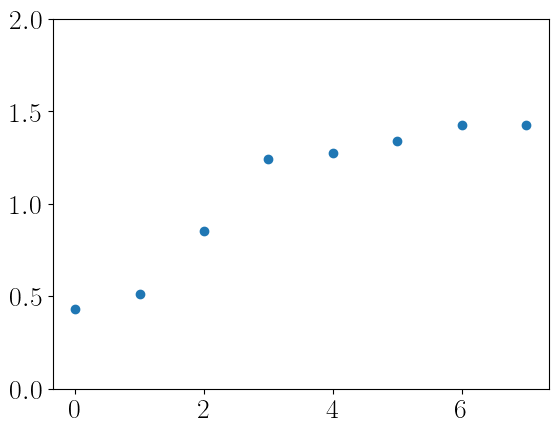

In [9]:
n_inp = 8
l = 0.05
u = 2
T = 10
V = 100

J = np.random.uniform(0.1, 2, n_inp)
print(J)
ham_args = [J, "open"]

plt.scatter(arange(n_inp), np.sort(J))
plt.ylim(0, 2)

In [67]:
labels_train = linspace(l, u, T)
# labels_train = np.sort(uniform(a, b, 20))
svs_train = []
for p in labels_train:
    ham = ham_func(n_inp, p, *ham_args)
    svs_train.append(sparse.linalg.eigsh(ham, 1, which="SA")[1].reshape(-1))

labels_test = linspace(l, u, V)
svs_test = []
for p in labels_test:
    ham = ham_func(n_inp, p, *ham_args)
    svs_test.append(sparse.linalg.eigsh(ham, 1, which="SA")[1].reshape(-1))

In [12]:
n_copies = 1
n_tot = n_inp*n_copies

#### Ansatzes

In [37]:
""" All 4^n Pauli matrices"""
n_pars = 4**n_tot
ansatz = zeros([4**n_tot, 2**n_tot, 2**n_tot], dtype=complex)
pauli_string_generator = product([I, X, Y, Z], repeat=n_tot)
for i in range(4**n_tot):
    ansatz[i] = reduce(kron, next(pauli_string_generator))

In [108]:
""" local neighbouring Paulies in a window of a given locality, with some symmetries """

# lazy (and inefficient); if locality>2, *does* contain terms like AIBIIIII with A and B being Paulies
locality = 3
ansatz = []
ansatz_st = []
op_gen = product([I, X, Y, Z], repeat=locality)
st_gen = product(["_", "X", "Y", "Z"], repeat=locality)
for line_op, line_st in zip(op_gen, st_gen):
    st_base = "".join(line_st[::-1]) + "_"*(n_tot - locality)
    if st_base.count("Z") % 2 == 1: # if does not commute with X^n (spin-flip symmetry)
        continue
    if st_base.count("Y") % 2 == 1: # if has imaginary entries (time-reversal symmetry)
        continue
    op_base = list(line_op[::-1]) + [I]*(n_tot - locality)
    for q in range(n_tot):
        st = st_base[-q:] + st_base[:-q]
        if st not in ansatz_st:
            op = op_base[-q:] + op_base[:-q]
            ansatz_st.append(st)
            ansatz.append(reduce(kron, op))

# ansatz_info = "%d-local_neighbouring_paulis" %locality
ansatz_info = "%d-local_neighbouring-with_symms" %locality
# ansatz_info = "%d-local_periodic_Paulies-no_Y" %locality

n_pars = len(ansatz)
n_pars

113

In [13]:
""" local neighbouring Paulies in a window of a given locality, with some symmetries """

# lazy (and inefficient); if locality>2, *does not* contain terms like AIBIIIII with A and B being Paulies
locality_max = 3
ansatz = []
ansatz_st = []
for locality in range(1, locality_max + 1):
    op_gen = product([I, X, Y, Z], repeat=locality)
    st_gen = product(["_", "X", "Y", "Z"], repeat=locality)
    for line_op, line_st in zip(op_gen, st_gen):
        st_base = "".join(line_st[::-1]) + "_"*(n_tot - locality)
        if st_base.count("Z") % 2 == 1: # if does not commute with X^n (spin-flip symmetry)
            continue
        if st_base.count("Y") % 2 == 1: # if has imaginary entries (time-reversal symmetry)
            continue
        op_base = list(line_op[::-1]) + [I]*(n_tot - locality)
        for q in range(n_tot - locality + 1): # for chain (not ring)
            st = st_base[-q:] + st_base[:-q]
            if st not in ansatz_st:
                op = op_base[-q:] + op_base[:-q]
                ansatz_st.append(st)
                ansatz.append(reduce(kron, op))

ansatz_info = "%d-local_neighbouring-chain-with_symms" %locality

n_pars = len(ansatz)
n_pars

90

In [131]:
""" local dispersed non-neighbouring Paulies """

# even more lazy (and even more inefficient); if locality>=2, contains terms like AIIIIBII with A and B being Paulies
locality = 3
ansatz = []
ansatz_st = []
op_gen = product([I, X, Y, Z], repeat=locality)
st_gen = product(["_", "X", "Y", "Z"], repeat=locality)
for op_line, st_line in zip(op_gen, st_gen):
    for ind_line in product([i for i in range(n_tot)], repeat=locality):
        op_base = [I]*n_tot
        st_base = ["_"]*n_tot
        for l in range(locality):
            op_base[ind_line[l]] = op_line[l]
            st_base[ind_line[l]] = st_line[l]
        st_base = "".join(st_base)
        if st_base not in ansatz_st:
            ansatz_st.append(st_base)
            ansatz.append(reduce(kron, op_base))

ansatz_info = "%d-local_nonneighbouring_Paulies" %locality
# ansatz_info = "%d-local_dispersed_Paulies-no_Y-flips" %locality

n_pars = len(ansatz)
n_pars

1789

## $L$ and $S$

#### Predict labels

In [134]:
L, S = compute_LS_pure(svs_train, ansatz, n_copies=n_copies)

Computing L and S: finished in 30.97 s28.05 s

In [135]:
# """ Parallel computing of L and S """

# def compute_LS_i(i):
#     np.random.seed(i); sleep(uniform(0, 1)) # retarded lame, but prints pretty
#     print("Computing L and S: i=%d \t" %i)
#     L_i = zeros(n_pars)
#     S_i = zeros([n_pars, n_pars])
#     sv_c = reduce(fkron_vec, [svs_train[i]]*n_copies)
#     for j in range(n_pars):
#         vec_loc = ansatz[j]@sv_c
#         L_i[j] = (sv_c.conj().T@vec_loc).real
#         for k in range(n_pars):
#             S_i[j][k] = (vec_loc.conj().T@ansatz[k]@sv_c).real
#     return L_i, S_i

# if __name__ == '__main__':
#     time_start_LS = time()
#     with Pool() as pool: 
#         LS_i_list = pool.map(compute_LS_i, [i for i in range(T)])
#     L = array([LS_i_list[i][0] for i in range(T)])
#     S = array([LS_i_list[i][1] for i in range(T)])
#     time_finish_LS = time() - time_start_LS
#     print("Computing L and S: completed in %.2f s" %time_finish_LS, end="\r")

In [136]:
labels_train_c = array(labels_train)**(1) # artifact
labels_test_c = array(labels_test)**(1) # artifact

In [137]:
w_ls = 1e0
w_var = 1e-4

pars = get_pars(labels_train_c, L, S, w_ls, w_var, method="lstsq")
# pars = train_obs_LS(labels_train_c, ansatz, L, S, method="Newton-CG", w_ls=w_ls, w_var=w_var)

In [138]:
time_start_infer = time()
expecs_train, expecs_der_train, disps_train, CFIs_train, QFIs_train, O = aux_info_ham(ham_func, labels_train, ham_args, n_inp, pars, ansatz, n_copies=n_copies, dp=1e-5)
expecs_test, expecs_der_test, disps_test, CFIs_test, QFIs_test, O = aux_info_ham(ham_func, labels_test, ham_args, n_inp, pars, ansatz, n_copies=n_copies, dp=1e-5)
time_finish_infer = time() - time_start_infer
print("Prediction finished in %d s" %time_finish_infer)

Prediction finished in 18 s


n=8 | c=1 | k=0.000100
T: 10 | V: 100
n_pars: 90

MSE:                    5.995531918805255e-06
Total variance:         1.6901281672569137
Total reduced variance: 1.7516824529441575
ising_ham_J
3-local_neighbouring-chain-with_symms


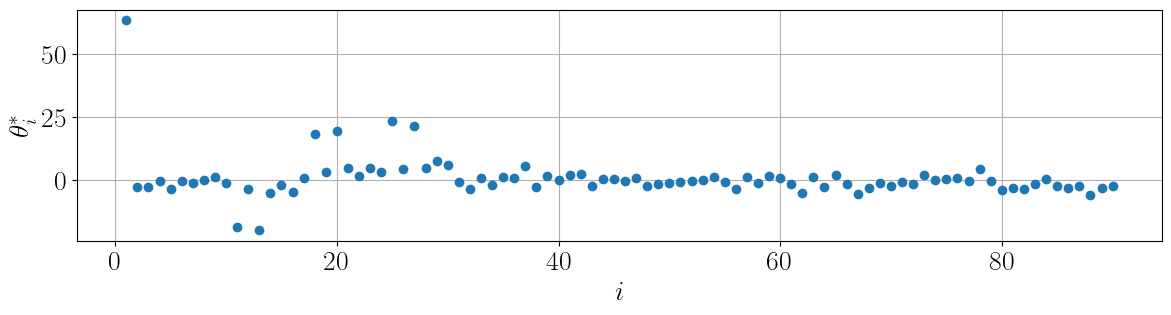

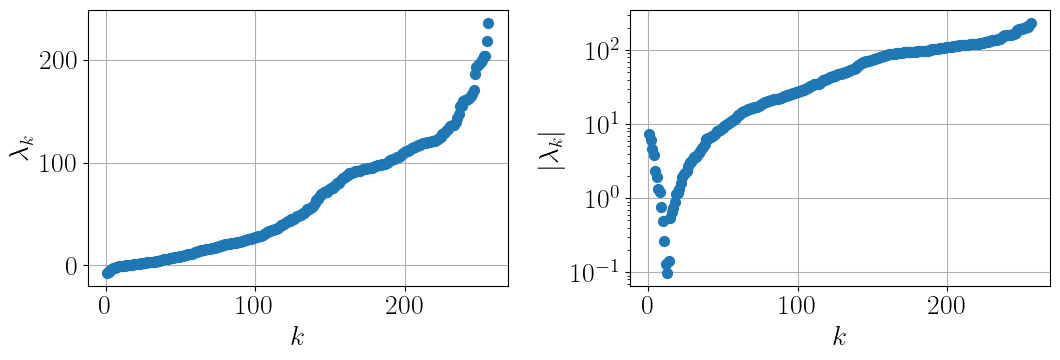

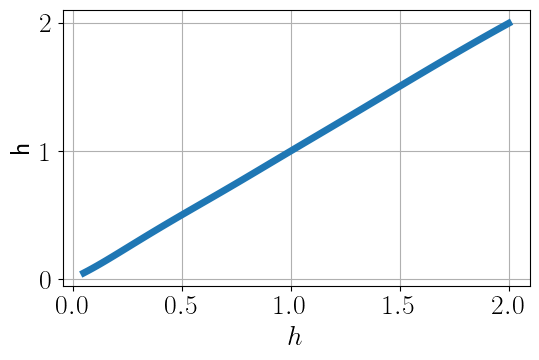

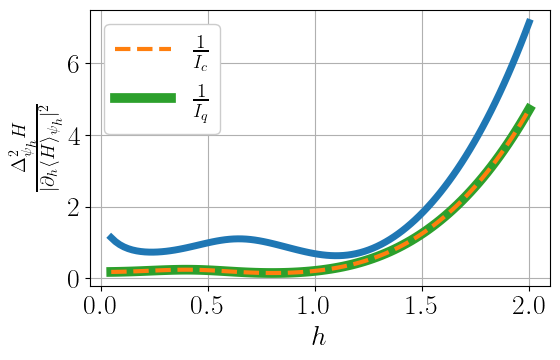

In [139]:
print("n=%d | c=%d | k=%f" %(n_inp, n_copies, w_var/w_ls))
print("T: %d | V: %d" %(T, V))
print("n_pars: %d" %n_pars)
print()
print("MSE:                   ", sum((expecs_test - labels_test_c)**2)/V)
print("Total variance:        ", sum(disps_test)/V)
print("Total reduced variance:", sum(disps_test/expecs_der_test**2)/V)
print(ham_name)
print(ansatz_info)

evals = eigh(O)[0] # .toarray()

plt.figure(figsize=(14, 3))
plt.scatter(arange(1, len(pars) + 1), pars)
# for i, txt in enumerate(ansatz_st):
#     plt.annotate(txt.replace("_", "–"), (i + 1, pars[i] + 0), fontsize=11, ha='left', rotation=90)
plt.xlabel(r"$i$")
plt.ylabel(r"$\theta_i^*$")
plt.grid()
plt.show()

plt.subplots(1, 2, figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.scatter(arange(1, 2**(n_inp*n_copies) + 1), evals, s=50)
plt.xlabel(r'$k$')
plt.ylabel(r'$\lambda_k$')
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(arange(1, 2**(n_inp*n_copies) + 1), np.abs(evals), s=50)
plt.xlabel(r'$k$')
plt.ylabel(r'$|\lambda_k|$')
plt.yscale("log")
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.rcParams['axes.axisbelow'] = True
# plt.plot(linspace(l, u), linspace(l, u), linestyle="-", linewidth=0.8, color="black")
# plt.scatter(labels_test_c, expecs_test, s=120, edgecolor='black', zorder=2) # , color="dodgerblue"
# plt.plot(labels_test_c, labels_test_c, linestyle="-", linewidth=0.8, color="black")
plt.plot(labels_test_c, expecs_test, linewidth=5, zorder=2) # , color="dodgerblue"
plt.plot(labels_test_c, labels_test_c, linewidth=1, zorder=1, color="black") # , color="dodgerblue"
# plt.axhline(0, color="black", zorder=1) # , color="dodgerblue"
plt.xlabel(r"$h$")
plt.ylabel(r"$\mathsf{h}$")
plt.grid()
plt.tight_layout()
# plt.savefig("ising-chain-est.pdf", transparent=True, bbox_inches='tight')
plt.show()

# plt.figure(figsize=(7, 4))
# plt.rcParams['axes.axisbelow'] = True
# # plt.plot(linspace(l, u), linspace(l, u), linestyle="-", linewidth=0.8, color="black")
# # plt.scatter(labels_test_c, expecs_test, s=120, edgecolor='black', zorder=2) # , color="dodgerblue"
# # plt.plot(labels_test_c, labels_test_c, linestyle="-", linewidth=0.8, color="black")
# plt.plot(labels_test_c, (expecs_test - labels_test_c)**2, linewidth=5, zorder=2) # , color="dodgerblue"
# plt.axhline(0, color="black", zorder=1) # , color="dodgerblue"
# plt.xlabel(r"$\alpha$")
# plt.ylabel(r"$(\mathsf{a} - \alpha)^2$")
# plt.grid()
# plt.tight_layout()
# # plt.savefig(path + info + "-squared-est.pdf", transparent=True, bbox_inches='tight')
# plt.show()

plt.figure(figsize=(6, 4))
plt.rcParams['axes.axisbelow'] = True
# plt.scatter(labels_test_c, disps_test/expecs_der_test**2, s=120, edgecolor='black', zorder=2)
plt.plot(labels_test_c, disps_test/expecs_der_test**2, linewidth=5, zorder=3)
plt.plot(labels_test, 1/CFIs_test, linestyle="--", linewidth=3, zorder=2, label=r"$\frac{1}{I_c}$")
plt.plot(labels_test, 1/QFIs_test, linestyle="-", linewidth=7, color="tab:green", zorder=1, label=r"$\frac{1}{I_q}$")
plt.xlabel(r"$h$")
plt.ylabel(r"$\frac{\Delta^2_{\psi_h} H}{|\partial_h \langle H \rangle_{\psi_h}|^2}$")
plt.grid()
# plt.yscale("log")
plt.tight_layout()
plt.legend(framealpha=1)
# plt.savefig("ising-chain-var.pdf", transparent=True, bbox_inches='tight')
plt.show()

In [140]:
path = Path() / "Results"
info = f"{ham_name}-{ansatz_info}-" + ("n=%d-c=%d-w_ls=%.1f-w_var=%.4f-n_pars=%d" %(n_inp, n_copies, w_ls, w_var, n_pars)).replace(" ", "")
note = "Ising Hamiltonian on chain, with growing couplings. The ansatz is 3-local neighboring Paulis on chain, with spin-flip and time-reversal symmetries."
file_name = str((path / (info + ".dict")).resolve())

data_dict = {
    "n": n_inp,
    "c": n_copies,
    "l": l,
    "u": u,
    "T": T,
    "V": V,
    "w_ls": w_ls, 
    "w_var": w_var, 
    "ham_name": ham_name,
    "ansatz_info": ansatz_info,
    # "ansatz": array(ansatz),
    # "ansatz": ansatz,
    "ansatz_st": ansatz_st,
    "L": L,
    "S": S,
    "note": "", 
    "pars": array(pars),
    "labels_train": array(labels_train),
    "labels_test": array(labels_test),
    "expecs_test": array(expecs_test),
    "expecs_der_test": array(expecs_der_test),
    "CFIs_test": array(CFIs_test),
    "QFIs": array(QFIs_test),
    "disps_test": array(disps_test),
    "note": note,
    "J": J,
    # "time_finish_LS": time_finish_LS,
} 

print(file_name)

with open(file_name, 'wb') as fp:
    pickle.dump(data_dict, fp, protocol=pickle.HIGHEST_PROTOCOL)

C:\Users\kardashin\Work\Measure-once_regression\Results\ising_ham_J-3-local_neighbouring-chain-with_symms-n=8-c=1-w_ls=1.0-w_var=0.0001-n_pars=90.dict


#### Filtering

			Iteration: 10 | Cost: 0.00384086 | Time passed: 0 s
Prediction finished in 17 s


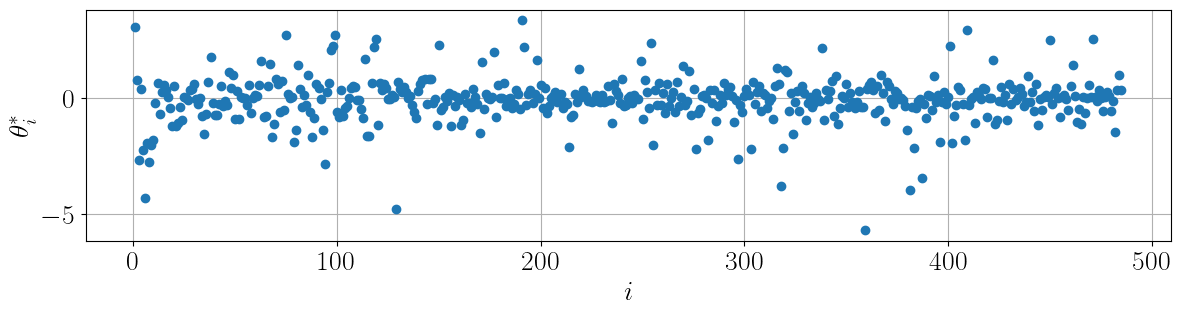

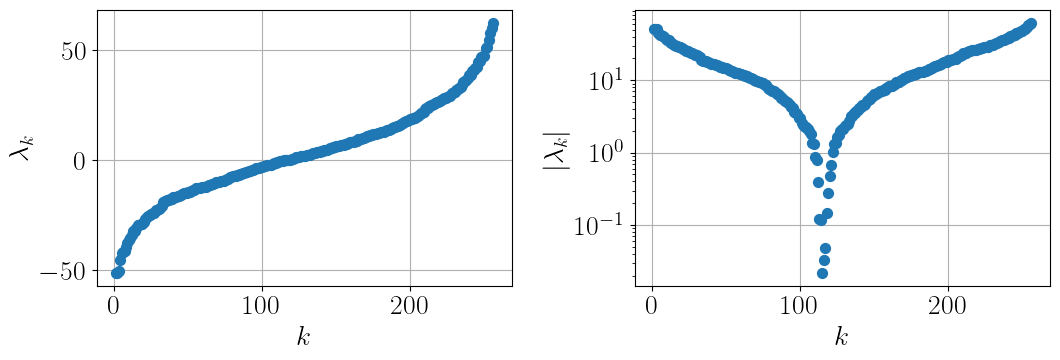

n=8 | c=1 | k=0.000100
T: 10 | V: 100
n_pars: 1789
eps: 0.010| n_pars filtered: 485

MSE:                    9.751009540524824e-05
Total variance:         3.1551909850249302
Total reduced variance: 3.4403935734010727


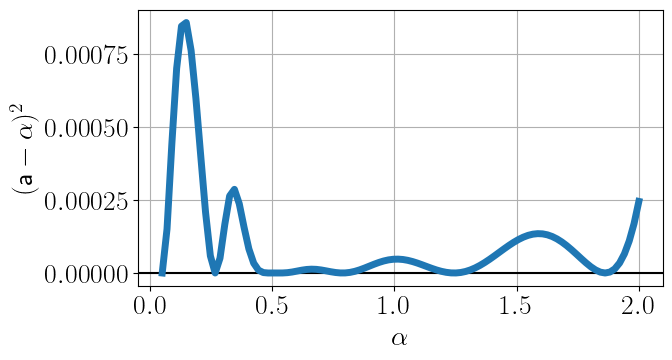

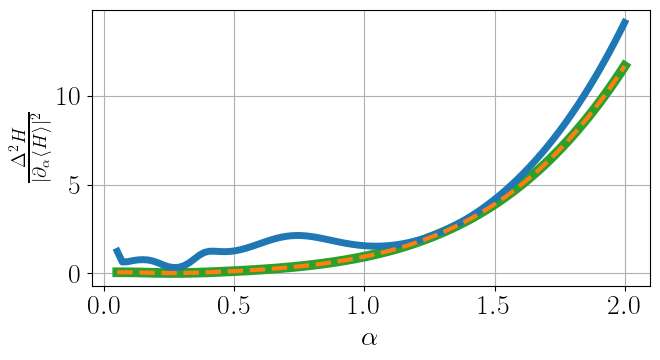

In [60]:
eps = 0.01
inds_filt = [i for i in range(n_pars) if abs(pars[i]) >= eps]
pars_filt = pars[inds_filt]
ansatz_filt = array(ansatz)[inds_filt]
ansatz_st_filt = list(array(ansatz_st)[inds_filt]) # lame

L_filt, S_filt = compute_LS_pure(svs_train, ansatz_filt, n_copies=n_copies)

# pars_filt = get_pars(labels_train_c, L_filt, S_filt, w_ls, w_var, method="lstsq")
pars_filt = train_obs_LS(labels_train_c, ansatz_filt, L_filt, S_filt, method="Newton-CG", w_ls=w_ls, w_var=w_var)

time_start = time()
expecs_train_filt, expecs_der_train_filt, disps_train_filt, CFIs_train_filt, QFIs_train, O_filt = aux_info_ham(ham_func, labels_train, ham_args, n_inp, pars_filt, ansatz_filt, n_copies=n_copies, dp=1e-5)
expecs_test_filt, expecs_der_test_filt, disps_test_filt, CFIs_test_filt, QFIs_test, O_filt = aux_info_ham(ham_func, labels_test, ham_args, n_inp, pars_filt, ansatz_filt, n_copies=n_copies, dp=1e-5)
time_finish = time() - time_start
print("Prediction finished in %d s" %time_finish)

evals_filt = eigh(O_filt)[0] # .toarray()

plt.figure(figsize=(14, 3))
plt.scatter(arange(1, len(pars_filt) + 1), pars_filt)
# for i, txt in enumerate(ansatz_st_filt):
#     plt.annotate(txt.replace("_", "–"), (i + 1, pars_filt[i] + 0.1), fontsize=11, ha='left', rotation=90)
plt.xlabel(r"$i$")
plt.ylabel(r"$\theta_i^*$")
plt.grid()
plt.show()

plt.subplots(1, 2, figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.scatter(arange(1, 2**(n_inp*n_copies) + 1), evals_filt, s=50)
plt.xlabel(r'$k$')
plt.ylabel(r'$\lambda_k$')
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(arange(1, 2**(n_inp*n_copies) + 1), np.abs(evals_filt), s=50)
plt.xlabel(r'$k$')
plt.ylabel(r'$|\lambda_k|$')
plt.yscale("log")
plt.grid()
plt.tight_layout()
plt.show()

print("n=%d | c=%d | k=%f" %(n_inp, n_copies, w_var/w_ls))
print("T: %d | V: %d" %(T, V))
print("n_pars: %d" %n_pars)
print("eps: %.3f| n_pars filtered: %d" %(eps, len(ansatz_filt)))
print()
print("MSE:                   ", sum((expecs_test_filt - labels_test_c)**2)/V)
print("Total variance:        ", sum(disps_test_filt)/V)
print("Total reduced variance:", sum(disps_test_filt/expecs_der_test_filt**2)/V)
# print(ansatz_info)

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
plt.plot(labels_test_c, (expecs_test_filt - labels_test_c)**2, linewidth=5, zorder=2) # , color="dodgerblue"
plt.axhline(0, color="black", zorder=1) # , color="dodgerblue"
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$(\mathsf{a} - \alpha)^2$")
plt.grid()
plt.tight_layout()
# plt.savefig(path + info + "-squared-est.pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
plt.plot(labels_test_c, disps_test_filt/expecs_der_test_filt**2, linewidth=5, zorder=2)
plt.plot(labels_test, 1/CFIs_test_filt, linestyle="--", linewidth=3, zorder=2)
plt.plot(labels_test, 1/QFIs_test, linestyle="-", linewidth=7, color="tab:green", zorder=1)
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\frac{\Delta^2 H}{|\partial_\alpha \langle H \rangle|^2}$")
plt.grid()
plt.tight_layout()
# plt.yscale("log")
# plt.legend()
# plt.savefig(path + info + "-squared-var.pdf", transparent=True, bbox_inches='tight')
plt.show()

In [28]:
# pars_filt = get_pars(labels_train_c, L_filt, S_filt, w_ls, w_var, method="pinv") # lstsq
pars_filt = train_obs_LS(labels_train_c, ansatz_filt, L_filt, S_filt, method="Newton-CG", w_ls=w_ls, w_var=w_var)

			Iteration: 10 | Cost: 0.00317499 | Time passed: 0 s
 Optimization terminated successfully.


In [21]:
for par, string in zip(pars_filt, ansatz_st_filt):
    print("%.4f | %s" %(par, string))

5.2912 | ________
-1.2800 | X_______
-0.3807 | _X______
-0.6046 | __X_____
0.6029 | ___X____
2.4650 | ____X___
1.5031 | _____X__
-2.2732 | ______X_
-2.0475 | _______X
-0.6565 | XX______
0.4132 | X_X_____
0.1089 | X__X____
0.0610 | X___X___
0.0094 | X____X__
0.0499 | X_____X_
0.1746 | X______X
0.0939 | _XX_____
2.4713 | _X_X____
1.4648 | _X__X___
0.3305 | _X___X__
0.1891 | _X____X_
-0.3956 | _X_____X
1.4450 | __XX____
1.6920 | __X_X___
-0.4831 | __X__X__
0.1318 | __X___X_
-0.8066 | __X____X
-0.6233 | ___XX___
1.3953 | ___X_X__
-1.3838 | ___X__X_
-0.6334 | ___X___X
-0.8457 | ____XX__
-1.5045 | ____X_X_
-1.0288 | ____X__X
-1.7089 | _____XX_
-0.5457 | _____X_X
1.0201 | ______XX
1.3139 | YY______
0.4552 | Y_Y_____
-0.0292 | Y__Y____
-0.0666 | Y___Y___
0.0448 | Y____Y__
-0.0137 | Y_____Y_
-0.2978 | Y______Y
-0.0013 | _YY_____
2.2454 | _Y_Y____
-1.4661 | _Y__Y___
0.4135 | _Y___Y__
-0.2253 | _Y____Y_
-0.3421 | _Y_____Y
-1.4309 | __YY____
1.6266 | __Y_Y___
0.5195 | __Y__Y__
0.1000 | __Y___Y_
0.

In [22]:
for par, string in zip(np.sort(pars_filt), array(ansatz_st_filt)[pars_filt.argsort()]):
    print("%.4f | %s" %(par, string))

-4.9697 | _XZZ____
-4.9186 | ____ZZ__
-3.9085 | ___ZZ___
-3.8378 | _____XXX
-3.7737 | ___XZZ__
-3.5583 | __XZ___Z
-2.7512 | X____ZZ_
-2.7143 | __XXX___
-2.6131 | ______ZZ
-2.5462 | X_Z__Z__
-2.5252 | XZ_____Z
-2.4650 | ____XZ_Z
-2.2786 | X_____ZZ
-2.2732 | ______X_
-2.2000 | XYY_____
-2.1525 | ____Z_XZ
-2.1281 | __X_ZZ__
-2.0976 | __XZ__Z_
-2.0562 | __ZZ___X
-2.0475 | _______X
-1.9205 | ____YX_Y
-1.8893 | _X_YY___
-1.8323 | __Z___Z_
-1.7899 | _XXX____
-1.7542 | __X__XX_
-1.7327 | ____Y_XY
-1.7248 | _YY_X___
-1.7089 | _____XX_
-1.7073 | _XY___Y_
-1.6921 | ____XY_Y
-1.6519 | X_YY____
-1.6301 | _Z__X_Z_
-1.5977 | __X_Z__Z
-1.5626 | __XZZ___
-1.5483 | __Z_X_Z_
-1.5284 | ___X_XX_
-1.5224 | ___XX_X_
-1.5183 | X_____XX
-1.5082 | __X_Y_Y_
-1.5045 | ____X_X_
-1.5004 | ___Z___Z
-1.5001 | ____Y_Y_
-1.4661 | _Y__Y___
-1.4501 | _Z___Z__
-1.4309 | __YY____
-1.4172 | _____ZZX
-1.3838 | ___X__X_
-1.3579 | X___XX__
-1.3501 | _Y__X_Y_
-1.2919 | ___XY_Y_
-1.2913 | X____YY_
-1.2893 | ____X_ZZ
-1.2814 | _Z

In [23]:
for par, string in zip(np.sort(pars), array(ansatz_st)[pars.argsort()]):
    print("%.4f | %s" %(par, string))

-11.4336 | ____ZZ__
-8.9429 | __XZ___Z
-7.7896 | X_Z__Z__
-7.5309 | _____XXX
-7.2078 | X_YY____
-6.9956 | ____XZ_Z
-6.7290 | X____ZZ_
-6.4066 | ____ZX_Z
-6.3190 | __YY____
-6.2927 | ___XZZ__
-6.2094 | __XZ__Z_
-5.9442 | ___ZZ___
-5.8198 | ____YX_Y
-5.4807 | X__Z___Z
-5.4047 | ___Y__YX
-5.0704 | _XXX____
-4.9670 | _____YXY
-4.7832 | _XZZ____
-4.6663 | _Z___Z__
-4.3968 | __Z___Z_
-4.3929 | ____Y_XY
-4.3740 | X___XX__
-4.1011 | _Y__Y___
-4.0377 | __X_Z_Z_
-3.9933 | ___XX_X_
-3.9186 | ____Z_XZ
-3.6867 | _X__YY__
-3.6469 | XZ___Z__
-3.5841 | ___Y__XY
-3.4874 | ____X_ZZ
-3.4859 | X__Z__Z_
-3.3418 | __XXX___
-3.2947 | __X_X_X_
-3.2511 | __X_Z__Z
-3.1626 | ____X__X
-3.1285 | __Y__Y_X
-3.1151 | _______X
-3.0400 | __X__XX_
-3.0170 | XYY_____
-3.0064 | __Z__XZ_
-2.9931 | X_____ZZ
-2.8397 | ___ZXZ__
-2.8244 | X__XX___
-2.7929 | __X_Y_Y_
-2.7926 | ___X__YY
-2.6363 | __X____X
-2.6325 | __X_XX__
-2.6258 | _ZZ__X__
-2.5389 | ___Z__XZ
-2.4673 | __Y_X__Y
-2.4266 | __X_____
-2.4202 | ___X_XX_
-2.4080 | X